In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy import special

<>:17: SyntaxWarning: invalid escape sequence '\z'
<>:17: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_273618/4292524970.py:17: SyntaxWarning: invalid escape sequence '\z'
  Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')


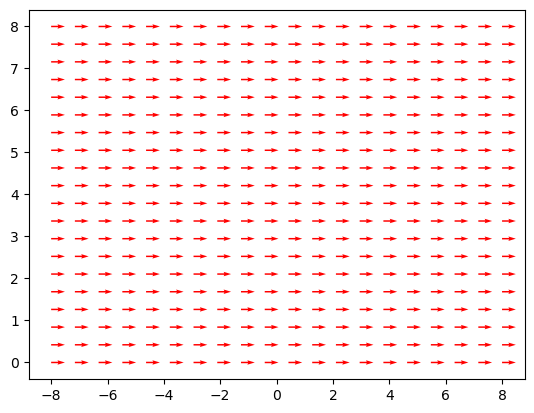

In [4]:
x_vals = np.linspace(-8,8,20)
y_vals = np.linspace(0,8,20)
#a = .142
#E_0 = 8e6
#f = 8e8

a = 300
f = 1/20
E_0 = 5

X, Y = np.meshgrid(x_vals,y_vals)
U = 0
V = 0

fig, ax = plt.subplots(1,1)

Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')

def update_quiver(frame_num, Q, X, Y):
    #U = 5 * special.jv(0, ((special.jn_zeros(0, 1) / 300 * Y))) * np.cos(frame_num/8)
    U = E_0 * special.jv(0, ((special.jn_zeros(0, 1) / a * Y))) * np.cos(frame_num * 2 * np.pi * f)
    V = 0 * X

    Q.set_UVC(U,V)

    return Q,

nframes = 60

anim = FuncAnimation(fig, update_quiver, fargs=(Q, X, Y), frames = nframes, interval=50)
display(HTML(anim.to_jshtml()))

<>:17: SyntaxWarning: invalid escape sequence '\z'
<>:17: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_273618/202863190.py:17: SyntaxWarning: invalid escape sequence '\z'
  Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')


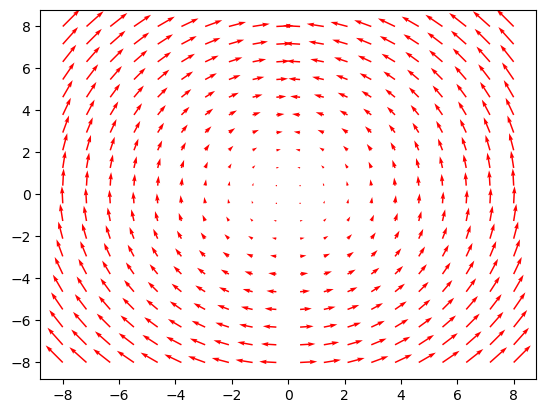

In [8]:
x_vals = np.linspace(-8,8,20)
y_vals = np.linspace(-8,8,20)
#a = .142
#E_0 = 8e6
#f = 8e8

a = 300
f = 1/20
E_0 = 5

X, Y = np.meshgrid(x_vals,y_vals)
U = 0
V = 0

fig, ax = plt.subplots(1,1)

Q = ax.quiver(X, Y, U, V, color='red', label='$E_{\z}$')

def function_of_H (E_0, z, r, a):
    H = (E_0 / 1) * special.jv(1, ((special.jn_zeros(0, 1)/a) * r))
    return H

def update_quiver(frame_num, Q, X, Y):
    theta = np.arctan(Y / X)
    phi = (np.pi / 2) + theta
    radius = np.sqrt(X**2 + Y**2)    
    
    #U = E_0 * special.jv(0, ((special.jn_zeros(0, 1) / a * Y))) * np.cos(frame_num * 2 * np.pi * f)
    #V = 0 * X

    H_x = function_of_H(E_0, 1,radius, a) * np.cos(phi + 0.1 * frame_num) 
    H_y = function_of_H(E_0, 1,radius, a) * np.sin(phi + 0.1 * frame_num) 

    #plt.quiver(X,Y, H_x, H_y, color='red', label='$H_{\phi}$')

    Q.set_UVC(H_x,H_y)

    return Q,

nframes = 60

anim = FuncAnimation(fig, update_quiver, fargs=(Q, X, Y), frames = nframes, interval=50)
display(HTML(anim.to_jshtml()))